# Adversarial Search: Playing "Mean" Connect 4


## Instructions

Total Points: Undegraduates 10, graduate students 11

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play "Mean" Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

> **The mean part:** This game has an additional rule. Every time it is a player's turn, the player can decide to instead of playing a new disk, take a bottom row disk of the opponent and place it in any column. All disks above the removed disk will fall down one position. Note that a player can only move an _opponent's disc_ that is in the _bottom row_ of the board.

Note that normal [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [1 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

### The problem search (Adversarial Search) được định nghĩa như sau:
* **Initial State:**  Bàn trò chơi kích thước $7 \times 6$ (7 cols - 6 rows). Ban đầu trống hoàn toàn.
    1. Trạng thái người chơi: (Max: 1) | (Min: -1) 
* **Actions:** Có 2 hành động cho người chơi chọn 1 để thực hiện mỗi lượt. 
    1. Đặt thẻ màu tròn vào cột mà chưa đầy.
    2. Lấy thẻ màu nằm ở hàng dưới cùng của đối thủ (nếu có) để đặt qua cột khác.
* **Transition model:** khi người chơi thực hiện hành động $a$ trong trạng thái bàn cờ $s$, thì trạng thái mới là $result(s,a)$
    1. Nếu hành động $a$ là đặt thẻ màu mới, thì thẻ sẽ rơi xuống vị trí thấp nhất còn trống trong cột đó.
    2. Nếu hành động $a$ là lấy thẻ màu của đối thủ ở hàng dưới cùng của đối thủ sẽ bị gỡ bỏ và đặt vào cột mới, đồng thời các quân phía trên nó sẽ `dịch xuống`.
* **Test for the terminal state:** 
    1. Một trong hai chiến thắng khi mà có 4 điểm liên tiếp cùng màu trên hàng, cột, đường chéo.
    2. Bàn trò chơi đầy thẻ màu mà chưa có ai thắng thì kết thúc hòa.
    + Biểu diễn: teminal(s) -> `True` thì trò chơi kết thúc, ngược lại `False` 
* **Utility for terminal states:**
    - Nếu người chơi `MAX` thắng -> $Utility(s)$ = +1
    - Nếu người chơi `MIN` thắng -> $Utility(s)$ = -1
    - Nếu hòa -> $Utility(s)$ = 0


How big is the state space? Give an estimate and explain it.

### State Space

**State space** = số tất cả các trạng thái bàn cờ có thể xảy ra.  

- Bàn cờ tiêu chuẩn 6x7 = 42 ô.  
- Mỗi ô có thể là:  
  - 0 → trống  
  - 1 → quân player_Max  
  - -1 → quân player_Min  

- Thực tế, **không phải mọi tổ hợp đều hợp lệ**:  
  - Các quân phải rơi đúng luật  
  - Mean move chỉ ảnh hưởng đến hàng dưới cùng  
- Vì vậy, số trạng thái hợp lệ thực tế sẽ nhỏ hơn nhiều nhưng vẫn rất lớn, khoảng 10¹⁶ – 10¹⁸ trạng thái.  

**Kết luận:**

- State space ≈ 10¹⁶ – 10¹⁸
- Giải thích: mỗi ô có 3 trạng thái nhưng ràng buộc rơi xuống làm giảm một chút số lượng, nhưng vẫn cực kỳ lớn.


How big is the game tree that minimax search will go through? Give an estimate and explain it.

### Game Tree (Minimax)

**Game tree** = tất cả các ván đi có thể xảy ra (mỗi nút là trạng thái, mỗi nhánh là một hành động hợp lệ).  

- **Số nước đi trung bình mỗi lượt**:  
  - Thả quân vào cột trống → tối đa 7 lựa chọn  
  - Thêm mean move → trung bình 10–15 hành động  
  - Gọi số hành động trung bình là **b ≈ 10**  

- **Chiều sâu tối đa**:  
  - Mỗi ván có tối đa 42 lượt (bàn đầy)  
  - Chiều sâu trung bình ≈ 20–30 lượt đến khi thắng  

- **Số nút trong game tree**:  
  - Xấp xỉ \(b^d\) với b = branching factor, d = depth  
  - Nếu b ≈ 10, d ≈ 20 → ≈ 10²⁰ nút → cực kỳ lớn  

**Kết luận:**

- Game tree size ≈ 10²⁰  
- Giải thích: branching factor ≈ 10 (thả quân + mean move), chiều sâu ≈ 20–30, số nút ≈ 10²⁰  


## Task 2: Game Environment and Random Agent [3 point]

You can use a numpy character array as the board. Note that the following function can create boards of different sizes.

In [45]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


Instead of colors (red and yellow), you can use 1 and -1 to represent the players Max and Min. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position and player is the player (1, -1) whose next move it is and who the agent should play.

Visualization code by Randolph Rankin:

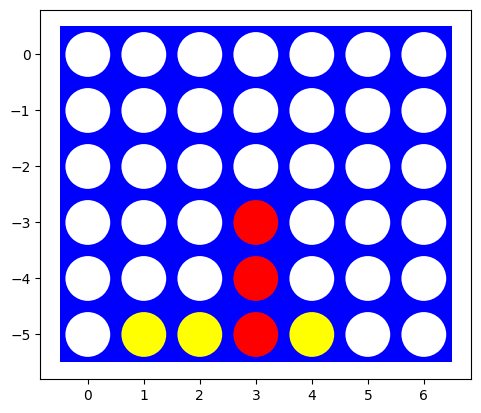

In [46]:
import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]

visualize(board)

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

Make sure that all these functions work with boards of different sizes (number of columns and rows).

In [47]:
import numpy as np

player_Max = 1
player_Min = -1

def actions(state, player):
    state = np.array(state)
    rows, cols = state.shape
    opp = -player
    acts = []
    for c in range(cols):
        if 0 in state[:, c]:
            acts.append((None, c))
    bottom_row = rows - 1
    for c in range(cols):
        if state[bottom_row, c] == opp:
            temp_state = state.copy()
            for r in range(bottom_row, 0, -1):
                temp_state[r, c] = temp_state[r - 1, c]
            temp_state[0, c] = 0
            for new_c in range(cols):
                if 0 in temp_state[:, new_c]:
                    acts.append((c, new_c))
    return acts

def result(state, player, action):
    state = np.array(state, copy=True)
    rows, cols = state.shape
    opp = -player
    bottom_row = rows - 1
    if action[0] is None:
        col = action[1]
        for r in range(rows - 1, -1, -1):
            if state[r, col] == 0:
                state[r, col] = player
                break
    else:
        from_col, to_col = action
        moving_disc = state[bottom_row, from_col]
        if moving_disc != opp:
            raise ValueError("Invalid mean move: không có quân đối thủ ở đáy cột")
        for r in range(bottom_row, 0, -1):
            state[r, from_col] = state[r - 1, from_col]
        state[0, from_col] = 0
        for r in range(rows - 1, -1, -1):
            if state[r, to_col] == 0:
                state[r, to_col] = moving_disc
                break
    return state.tolist()

def check_board(state):
    state = np.array(state)
    rows, cols = state.shape
    for r in range(rows):
        for c in range(cols):
            player = state[r][c]
            if player == 0:
                continue
            if c + 3 < cols and all(state[r][c+i] == player for i in range(4)):
                return player
            if r + 3 < rows and all(state[r+i][c] == player for i in range(4)):
                return player
            if r + 3 < rows and c + 3 < cols and all(state[r+i][c+i] == player for i in range(4)):
                return player
            if r + 3 < rows and c - 3 >= 0 and all(state[r+i][c-i] == player for i in range(4)):
                return player
    if not (0 in state):
        return 0
    return None


def terminal(state):
    return check_board(state) is not None


def utility(state, player=player_Max):
    goal = check_board(state)
    if goal == player:
        return +1
    elif goal == 0:
        return 0
    elif goal == -player:
        return -1
    return None


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on bt yhe environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

Random player chọn hành động: (4, 3)


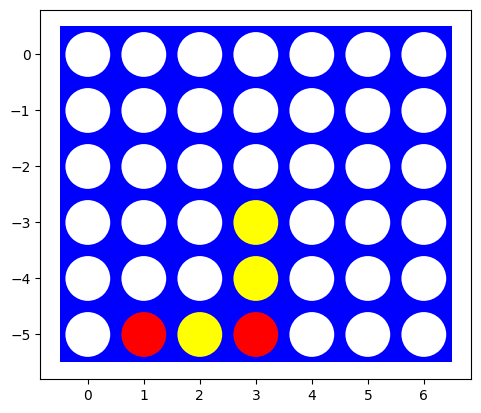

In [48]:
# Your code/ answer goes here.
import random

def random_player(board, player=None):
    valid_actions = actions(board, player)
    if not valid_actions:
        return None
    return random.choice(valid_actions)

board = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, -1, 0, 0, 0],
    [0, 1, -1, 1, -1, 0, 0],
]
action = random_player(board, player=1)
print("Random player chọn hành động:", action)
new_state = result(board, player=1, action=action)
visualize(new_state)

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [49]:
# Your code/ answer goes here.
def play(player_Max, player_Min, N=1000, show_final_board=False):
    results = {1: 0, -1: 0, 0: 0}
    for i in range(N):
        board = np.zeros((6,7), dtype=int).tolist()
        current_player = 1
        while True:
            if current_player == 1:
                action = player_Max(board, current_player)
            else:
                action = player_Min(board, current_player)
            if action is None:
                break
            board = result(board, current_player, action)
            winner = check_board(board)
            if winner is not None:
                results[winner] += 1
                break
            current_player *= -1
        if show_final_board:
            print(f"\nVán {i+1}")
            visualize(board)
    return results

results = play(random_player, random_player, N=1000)
print("Kết quả sau 1000 ván:")
print(f"Player_Max: {results[1]} thắng")
print(f"Player_Min: {results[-1]} thắng")
print(f"Hòa: {results[0]}")


Kết quả sau 1000 ván:
Player_Max: 756 thắng
Player_Min: 244 thắng
Hòa: 0


## Task 3: Minimax Search with Alpha-Beta Pruning [3 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for a $6 \times 7$ board is large. You can experiment with smaller boards (the smallest is $4 \times 4$) and/or changing the winning rule to connect 3 instead of 4.

In [50]:
# Your code/ answer goes here.
import math
import numpy as np

DEBUG = 1
COUNT = 0
DEPTH_LIMIT = 1

def alpha_beta_search(board, player=1, depth_limit=DEPTH_LIMIT):
    global DEBUG, COUNT
    COUNT = 0
    value, move = max_value_ab(board, player, -math.inf, +math.inf, 0, depth_limit)
    if DEBUG >= 1:
        print(f"Số nút đã duyệt: {COUNT}")
    return {"move": move, "value": value}


def max_value_ab(state, player, alpha, beta, depth, depth_limit):
    global DEBUG, COUNT
    COUNT += 1
    if terminal(state) or depth >= depth_limit:
        v = utility(state, player)
        return (v if v is not None else 0), None
    v, move = -math.inf, None
    for a in actions(state, player):
        v2, _ = min_value_ab(result(state, player, a), player, alpha, beta, depth + 1, depth_limit)
        if v2 > v:
            v, move = v2, a
        alpha = max(alpha, v)
        if v >= beta:
            break
    return v, move


def min_value_ab(state, player, alpha, beta, depth, depth_limit):
    global DEBUG, COUNT
    COUNT += 1
    if terminal(state) or depth >= depth_limit:
        v = utility(state, player)
        return (v if v is not None else 0), None
    v, move = +math.inf, None
    opponent = -player
    for a in actions(state, opponent):
        v2, _ = max_value_ab(result(state, opponent, a), player, alpha, beta, depth + 1, depth_limit)
        if v2 < v:
            v, move = v2, a
        beta = min(beta, v)
        if v <= alpha:
            break
    return v, move


def minimax_player(board, player=None):
    result_search = alpha_beta_search(board, player, depth_limit=4)
    if DEBUG == 1 or DEBUG == 2:
        print(f"Minimax chọn hành động: {result_search['move']} (giá trị {result_search['value']})")
    return result_search["move"]


board = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, -1, 0, 0, 0, 0],
    [1, 1, 1, 0, -1, -1, 0],
]

move = minimax_player(board, player=1)

Số nút đã duyệt: 1963
Minimax chọn hành động: (None, 3) (giá trị 1)


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

TH 1: Cơ hội thắng theo hàng ngang


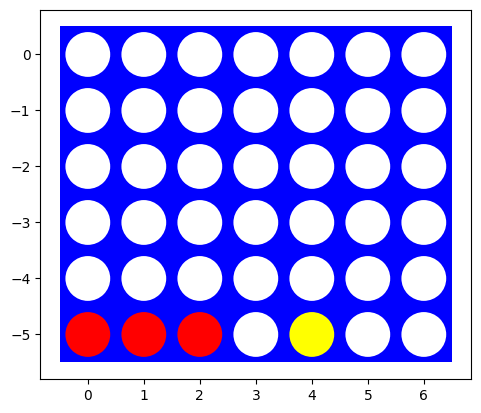

Số nút đã duyệt: 1244
Minimax chọn hành động: (None, 3) (giá trị 1)
Bước đi đề xuất kế tiếp:  (None, 3)
------------------------------------------------------------
TH 2: Cơ hội thắng theo cột dọc


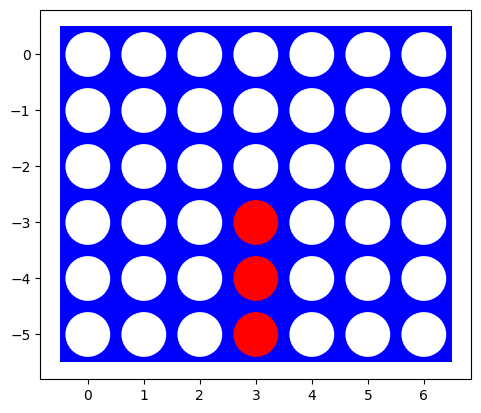

Số nút đã duyệt: 774
Minimax chọn hành động: (None, 3) (giá trị 1)
Bước đi đề xuất kế tiếp:  (None, 3)
------------------------------------------------------------
TH 3: Cơ hội thắng theo đường chéo


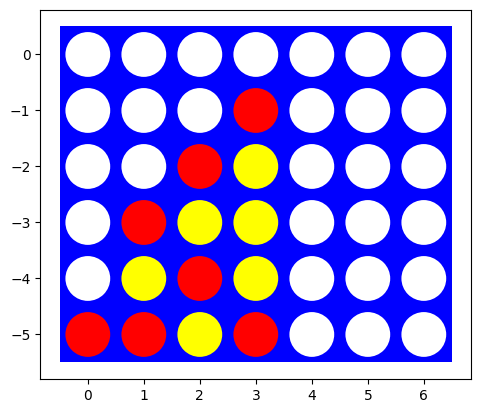

Số nút đã duyệt: 144
Minimax chọn hành động: (None, 0) (giá trị 1)
Bước đi đề xuất kế tiếp:  (None, 0)
------------------------------------------------------------
TH 4: Chặn nước thắng của đối thủ


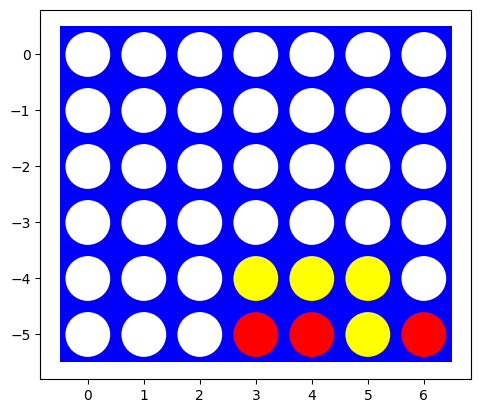

Số nút đã duyệt: 5232
Minimax chọn hành động: (None, 6) (giá trị 0)
Bước đi đề xuất kế tiếp:  (None, 6)
------------------------------------------------------------
TH 5: Cơ hội thực hiện nước đi 'mean move'


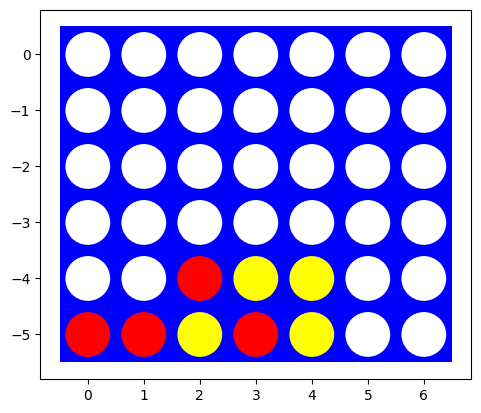

Số nút đã duyệt: 2809
Minimax chọn hành động: (2, 0) (giá trị 1)
Bước đi đề xuất kế tiếp:  (2, 0)
------------------------------------------------------------


In [51]:
# Your code/ answer goes here.
board1 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [1,1,1,0,-1,0,0],
]
print("TH 1: Cơ hội thắng theo hàng ngang")
visualize(board1)
move = minimax_player(board1, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board2 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,1,0,0,0],
]
print("TH 2: Cơ hội thắng theo cột dọc")
visualize(board2)
move = minimax_player(board2, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board3 = [
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,1,-1,0,0,0],
    [0,1,-1,-1,0,0,0],
    [0,-1,1,-1,0,0,0],
    [1,1,-1,1,0,0,0],
]
print("TH 3: Cơ hội thắng theo đường chéo")
visualize(board3)
move = minimax_player(board3, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board4 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,-1,-1,-1,0],
    [0,0,0,1,1,-1,1],
]
print("TH 4: Chặn nước thắng của đối thủ")
visualize(board4)
move = minimax_player(board4, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board5 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,1,-1,-1,0,0],
    [1,1,-1,1,-1,0,0],
]
print("TH 5: Cơ hội thực hiện nước đi 'mean move'")
visualize(board5)
move = minimax_player(board5, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [52]:
# Your code/ answer goes here.
board1 = [
    [0,0,0,0],
    [0,0,0,0],
    [0,0,0,0],
    [0,0,0,0],
    [0,0,1,0],
    [0,-1,-1,1],
]
board2 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,-1,-1,1,0,0,0],
]
print("Kích thước 4 cột:")
%time display(minimax_player(board1, player=1))
print("-"*60)
print("Kích thước 7 cột:")
%time display(minimax_player(board2, player=1))

Kích thước 4 cột:
Số nút đã duyệt: 498
Minimax chọn hành động: (None, 0) (giá trị 0)


(None, 0)

CPU times: total: 31.2 ms
Wall time: 29.4 ms
------------------------------------------------------------
Kích thước 7 cột:
Số nút đã duyệt: 1701
Minimax chọn hành động: (None, 0) (giá trị 0)


(None, 0)

CPU times: total: 125 ms
Wall time: 141 ms


### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

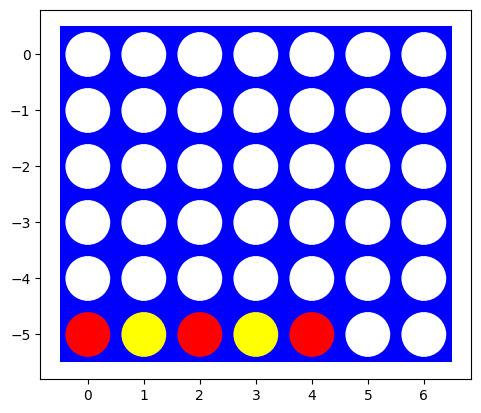

[(None, 3), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (None, 2), (None, 4), (None, 1), (None, 5), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (None, 0), (None, 6)]
------------------------------------------------------------
[(None, 0), (None, 1), (None, 2), (None, 3), (None, 4), (None, 5), (None, 6), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]


In [53]:
# Your code/ answer goes here.
def actions_ordered(state, player):
    state = np.array(state)
    rows, cols = state.shape
    opp = -player
    acts = []
    for c in range(cols):
        if 0 in state[:, c]:
            acts.append((None, c))
    bottom_row = rows - 1
    for c in range(cols):
        if state[bottom_row, c] == opp:
            temp_state = state.copy()
            for r in range(bottom_row, 0, -1):
                temp_state[r, c] = temp_state[r - 1, c]
            temp_state[0, c] = 0
            for new_c in range(cols):
                if 0 in temp_state[:, new_c]:
                    acts.append((c, new_c))
    center = cols // 2
    acts.sort(key=lambda a: abs((a[1] if a[0] is None else a[0]) - center))
    return acts

board =[[0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [1,-1,1,-1,1,0,0],
    ]
visualize(board)
move = actions_ordered(board, player=1)
print(move)
print("-"*60)
move1 = actions(board, player=1)
print(move1)


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

### Nước đi đầu tiên (The first few moves)
Khi bắt đầu với **bàn cờ trống**, thuật toán **Minimax kết hợp Alpha-Beta Pruning** sẽ rơi vào tình huống **tệ nhất**,  
vì không có thông tin nào để cắt tỉa nhánh. Do đó, thuật toán phải xem xét gần như **toàn bộ cây trò chơi**,  
gây tốn thời gian tính toán rất lớn.
Ví dụ, với bàn **6×7**, mỗi lượt có thể có 7 hành động hợp lệ và tối đa 42 lượt chơi,  
kích thước cây trò chơi rất lớn:
→ Không thể duyệt hết được trong thời gian hợp lý, ngay cả khi có Alpha-Beta Pruning.
### Giải pháp đề xuất

1. **Giới hạn độ sâu tìm kiếm (Depth Limit)**  
   - Chỉ tìm kiếm đến một độ sâu cố định (ví dụ: 3 hoặc 4).  
   - Khi đạt đến giới hạn, ta dừng lại và đánh giá trạng thái bằng hàm heuristic.

2. **Sử dụng hàm đánh giá heuristic (Heuristic Evaluation Function)**  
   - Dùng để ước lượng “độ tốt” của bàn cờ khi chưa có kết quả thắng/thua.  
   - Ví dụ: ưu tiên các vị trí trung tâm hoặc các chuỗi 2–3 quân liên tiếp.

3. **Áp dụng chiến lược sắp xếp nước đi (Move Ordering)**  
   - Duyệt các nước đi “có triển vọng” nhất trước (như đặt ở giữa bàn).  
   - Giúp Alpha-Beta Pruning cắt tỉa nhanh hơn giúp giảm thời gian tìm kiếm.

4. **Giảm kích thước bàn hoặc thay đổi luật thắng**  
   - Thử với bàn **4×4** và luật **nối 3 thay vì 4**,  
   - Cây trò chơi nhỏ hơn nhiều, giúp kiểm thử nhanh hơn.

5. **Dùng tìm kiếm mở rộng dần (Iterative Deepening Search)**  
   - Tăng dần độ sâu tìm kiếm theo thời gian cho phép,  
   - Giúp đảm bảo có được nước đi hợp lý trong giới hạn thời gian.

### Kết luận
Nhờ kết hợp các kỹ thuật trên, việc ra quyết định cho nước đi đầu tiên, vốn là trường hợp nặng nhất về tính toán sẽ trở nên khả thi và hiệu quả hơn nhiều.

### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [54]:
# Your code/ answer goes here.
DEBUG = 0
COUNT = 0
DEPTH_LIMIT = 4
play(minimax_player, random_player, 1)

{1: 1, -1: 0, 0: 0}

## Task 4: Heuristic Alpha-Beta Tree Search [3 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [55]:
# Your code/ answer goes here.
def heuristic_evaluation(board, player):
    state = np.array(board)
    rows, cols = state.shape
    opp = -player
    score = 0
    center_col = cols // 2
    center_array = [state[r][center_col] for r in range(rows)]
    score += 3 * center_array.count(player)
    score -= 3 * center_array.count(opp)
    def evaluate_window(window, player):
        opp = -player
        if list(window).count(player) == 4:
            return 100
        elif list(window).count(player) == 3 and list(window).count(0) == 1:
            return 5
        elif list(window).count(player) == 2 and list(window).count(0) == 2:
            return 2
        elif list(window).count(opp) == 3 and list(window).count(0) == 1:
            return -4
        else:
            return 0
    for r in range(rows):
        for c in range(cols - 3):
            window = state[r, c:c+4]
            score += evaluate_window(window, player)
    for c in range(cols):
        for r in range(rows - 3):
            window = state[r:r+4, c]
            score += evaluate_window(window, player)
    for r in range(rows - 3):
        for c in range(cols - 3):
            window = [state[r+i][c+i] for i in range(4)]
            score += evaluate_window(window, player)
    for r in range(rows - 3):
        for c in range(3, cols):
            window = [state[r+i][c-i] for i in range(4)]
            score += evaluate_window(window, player)
    return score

board =[[0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,0,0,0,0,0],
        [0,0,-1,-1,0,0,0],
        [1,-1,1,1,1,0,0],
    ]
heuristic_evaluation(board, player=1)

7

### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [56]:
# Your code/ answer goes here.
import math
import numpy as np

def alpha_beta_search_cutoff(board, player=1, depth_limit=3):
    value, move = max_value_ab_cutoff(board, player, -math.inf, math.inf, 0, depth_limit)
    return {"move": move, "value": value}

def max_value_ab_cutoff(state, player, alpha, beta, depth, depth_limit):
    if terminal(state):
        return utility(state, player), None
    if depth >= depth_limit:
        return heuristic_evaluation(state, player), None

    v, move = -math.inf, None
    for a in actions(state, player):
        v2, _ = min_value_ab_cutoff(result(state, player, a), player, alpha, beta, depth + 1, depth_limit)
        if v2 > v:
            v, move = v2, a
        alpha = max(alpha, v)
        if v >= beta:
            break
    return v, move

def min_value_ab_cutoff(state, player, alpha, beta, depth, depth_limit):
    if terminal(state):
        return utility(state, player), None
    if depth >= depth_limit:
        return heuristic_evaluation(state, player), None
    v, move = math.inf, None
    opp = -player
    for a in actions(state, opp):
        v2, _ = max_value_ab_cutoff(result(state, opp, a), player, alpha, beta, depth + 1, depth_limit)
        if v2 < v:
            v, move = v2, a
        beta = min(beta, v)
        if v <= alpha:
            break
    return v, move

def minimax_player_cutoff(board, player=None):
    result_search = alpha_beta_search_cutoff(board, player, depth_limit=4)
    if DEBUG == 1 or DEBUG == 2:
        print(f"Minimax chọn hành động: {result_search['move']} (giá trị {result_search['value']})")
    return result_search["move"]

board = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,-1,0,0,0],
    [1,1,-1,1,-1,0,0],
]

depth = 1
search_result = alpha_beta_search_cutoff(board, player=1, depth_limit=depth)
print(f"Độ sâu {depth}: hành động = {search_result['move']}, giá trị = {search_result['value']}")


Độ sâu 1: hành động = (None, 3), giá trị = 5


Experiment with the same manually created boards as above to check if the agent spots winning opportunities.

TH 1: Cơ hội thắng theo hàng ngang


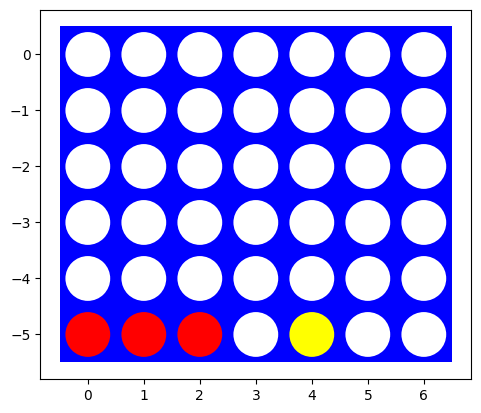

Bước đi đề xuất kế tiếp:  {'move': (None, 4), 'value': 8}
------------------------------------------------------------
TH 2: Cơ hội thắng theo cột dọc


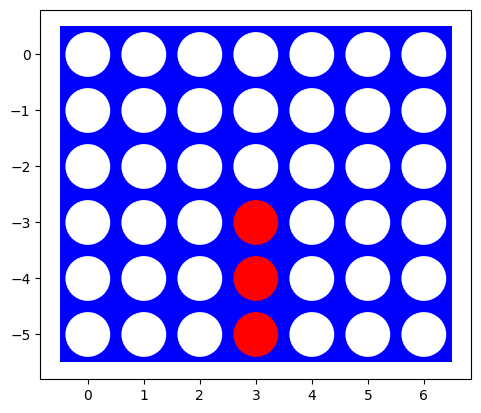

Bước đi đề xuất kế tiếp:  {'move': (None, 0), 'value': 1}
------------------------------------------------------------
TH 3: Cơ hội thắng theo đường chéo


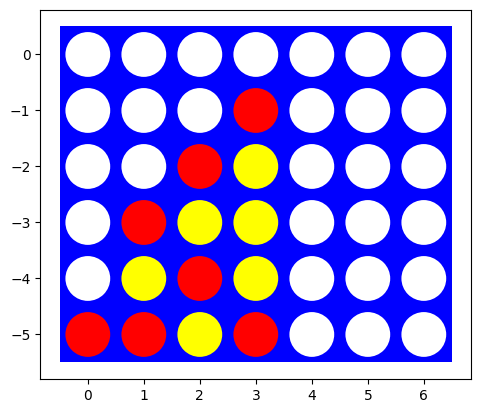

Bước đi đề xuất kế tiếp:  {'move': (None, 2), 'value': 12}
------------------------------------------------------------
TH 4: Chặn nước thắng của đối thủ


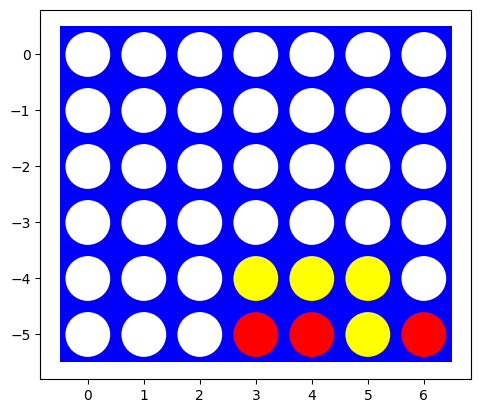

Bước đi đề xuất kế tiếp:  {'move': (5, 0), 'value': 2}
------------------------------------------------------------
TH 5: Cơ hội thực hiện nước đi 'mean move'


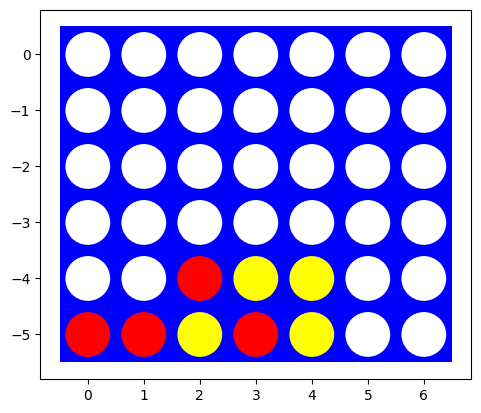

Bước đi đề xuất kế tiếp:  {'move': (None, 3), 'value': 10}
------------------------------------------------------------


In [57]:
# Your code/ answer goes here.
# Your code/ answer goes here.
board1 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [1,1,1,0,-1,0,0],
]
print("TH 1: Cơ hội thắng theo hàng ngang")
visualize(board1)
move = alpha_beta_search_cutoff(board1, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board2 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,1,0,0,0],
]
print("TH 2: Cơ hội thắng theo cột dọc")
visualize(board2)
move = alpha_beta_search_cutoff(board2, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board3 = [
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,1,-1,0,0,0],
    [0,1,-1,-1,0,0,0],
    [0,-1,1,-1,0,0,0],
    [1,1,-1,1,0,0,0],
]
print("TH 3: Cơ hội thắng theo đường chéo")
visualize(board3)
move = alpha_beta_search_cutoff(board3, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board4 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,-1,-1,-1,0],
    [0,0,0,1,1,-1,1],
]
print("TH 4: Chặn nước thắng của đối thủ")
visualize(board4)
move = alpha_beta_search_cutoff(board4, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


board5 = [
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0],
    [0,0,1,-1,-1,0,0],
    [1,1,-1,1,-1,0,0],
]
print("TH 5: Cơ hội thực hiện nước đi 'mean move'")
visualize(board5)
move = alpha_beta_search_cutoff(board5, player=1)
print("Bước đi đề xuất kế tiếp: ", move)
print("-"*60)


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [58]:
# Your code/ answer goes here.
board4 = empty_board(shape=(6,4))
board7 = empty_board()
print('-'*60)
print('Bàn cờ có cột: 4')
%time display(alpha_beta_search_cutoff(board4, player=1))
print('-'*60)
print('Bàn cờ có cột: 7')
%time display(alpha_beta_search_cutoff(board7, player=1))

------------------------------------------------------------
Bàn cờ có cột: 4


{'move': (None, 2), 'value': 3}

CPU times: total: 31.2 ms
Wall time: 8.56 ms
------------------------------------------------------------
Bàn cờ có cột: 7


{'move': (None, 3), 'value': 5}

CPU times: total: 109 ms
Wall time: 108 ms


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [59]:
# Your code/ answer goes here.
play(minimax_player_cutoff,minimax_player_cutoff, 1)

{1: 1, -1: 0, 0: 0}

## Tournament task [+ 1 to 5 bonus point will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [1 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+1 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [60]:
# Your code/ answer goes here.

### Best First Move

How would you determine what the best first move for a standard board ($6 \times 7$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [61]:
# Your code/ answer goes here.